In [1]:
import warnings
warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from binance import Client
from secrets import binance_api_key, binance_secret_key

In [12]:
client = Client(binance_api_key, binance_secret_key)
def get_tickers():
    tickers = []
    for info in client.futures_mark_price():
        ticker = info['symbol']
        if ticker[-4:] == "USDT":
            tickers.append(info['symbol'])
    return tickers

def get_sample(ticker, start_date="1 Jan, 2021"):
    klines = np.array(client.futures_historical_klines(ticker, Client.KLINE_INTERVAL_1DAY, start_date))
    sample = pd.DataFrame(klines.reshape(-1, 12), dtype=float, columns=['datetime',
                                                                        'open', 
                                                                        'high', 
                                                                        'low', 
                                                                        'close', 
                                                                        'volume', 
                                                                        'close time', 
                                                                        'quote asset volume, number of trades', 
                                                                        'number of trades',
                                                                        'taker buy base asset volume', 
                                                                        'taker buy quote asset volume', 
                                                                        'ignore'])
    sample['datetime'] = pd.to_datetime(sample['datetime'], unit='ms')
    sample.set_index('datetime', inplace=True)
    sample = sample[['open', 'high', 'low', 'close', 'volume']].copy()
    return sample

sample = get_sample("BTCUSDT")
sample.tail()

print(len(get_tickers()))

134


In [13]:
tickers = get_tickers()
ref = get_sample("ETHUSDT", start_date="1 Jan, 2020")
pre_samples = dict()
for ticker in tickers:
    sample = get_sample(ticker, start_date="1 Jan, 2020")
    if len(sample) < 220: continue
    
    # preprocess
    sample['noise'] = 1.-abs(sample['close'] - sample['open'])/(sample['high'] - sample['low'])
    sample['noise15'] = sample['noise'].rolling(10).mean()
    sample['target_up'] = sample['open'] + sample['noise15']*(sample.shift(1)['high'] - sample.shift(1)['low'])
    sample['target_down'] = sample['open'] - sample['noise15']*(sample.shift(1)['high'] - sample.shift(1)['low'])
    sample['momentum'] = (sample['close'] - sample.shift(10)['close'])/sample.shift(10)['close']
    sample['reward_up'] = 1. + sample['close'].pct_change()
    sample['reward_down'] = 1. - sample['close'].pct_change()
    sample['log_reward_up'] = np.log(sample['reward_up'])
    sample['log_reward_down'] = np.log(sample['reward_down'])
    sample['total_reward'] = sample['reward_up'].cumprod()
    sample.dropna(inplace=True)
    
    pre_samples[ticker] = sample.copy(); del sample
pre_samples['ETHUSDT'].tail(10)

,open,high,low,close,volume,noise,noise15,target_up,target_down,momentum,reward_up,reward_down,log_reward_up,log_reward_down,total_reward
datetime,,,,,,,,,,,,,,,
2021-11-18,4288.00,4343.33,3957.96,3997.72,2286170.467,0.246750,0.618802,4435.274906,4140.725094,-0.169616,0.932306,1.067694,-0.070094,0.065501,30.605727
2021-11-19,3997.72,4309.04,3973.14,4293.44,1514406.552,0.119619,0.591583,4225.698394,3769.741606,-0.093251,1.073972,0.926028,0.071364,-0.076851,32.869698
2021-11-20,4293.44,4436.01,4202.24,4412.55,1143613.530,0.490482,0.564671,4483.113057,4103.766943,-0.047420,1.027742,0.972258,0.027364,-0.028134,33.781580
2021-11-21,4412.37,4425.73,4242.00,4259.23,996488.568,0.166494,0.525218,4535.150298,4289.589702,-0.097848,0.965254,1.034746,-0.035364,0.034156,32.607794
2021-11-22,4259.28,4327.75,4019.35,4086.57,1891091.913,0.439981,0.487434,4348.836294,4169.723706,-0.124179,0.959462,1.040538,-0.041382,0.039738,31.285944
2021-11-23,4086.41,4387.00,4059.55,4341.36,1636864.585,0.221408,0.427127,4218.136063,3954.683937,-0.065252,1.062348,0.937652,0.060482,-0.064377,33.236564
2021-11-24,4341.36,4377.00,4170.38,4271.29,1365898.959,0.660875,0.401349,4472.781746,4209.938254,-0.077364,0.983860,1.016140,-0.016272,0.016011,32.700122
2021-11-25,4271.29,4558.29,4250.34,4527.86,1247655.550,0.166845,0.345266,4342.628791,4199.951209,-0.008572,1.060069,0.939931,0.058334,-0.061948,34.664370
2021-11-26,4528.20,4555.00,3911.00,4040.66,2657050.069,0.242950,0.342528,4633.681441,4422.718559,-0.040091,0.892399,1.107601,-0.113841,0.102196,30.934466


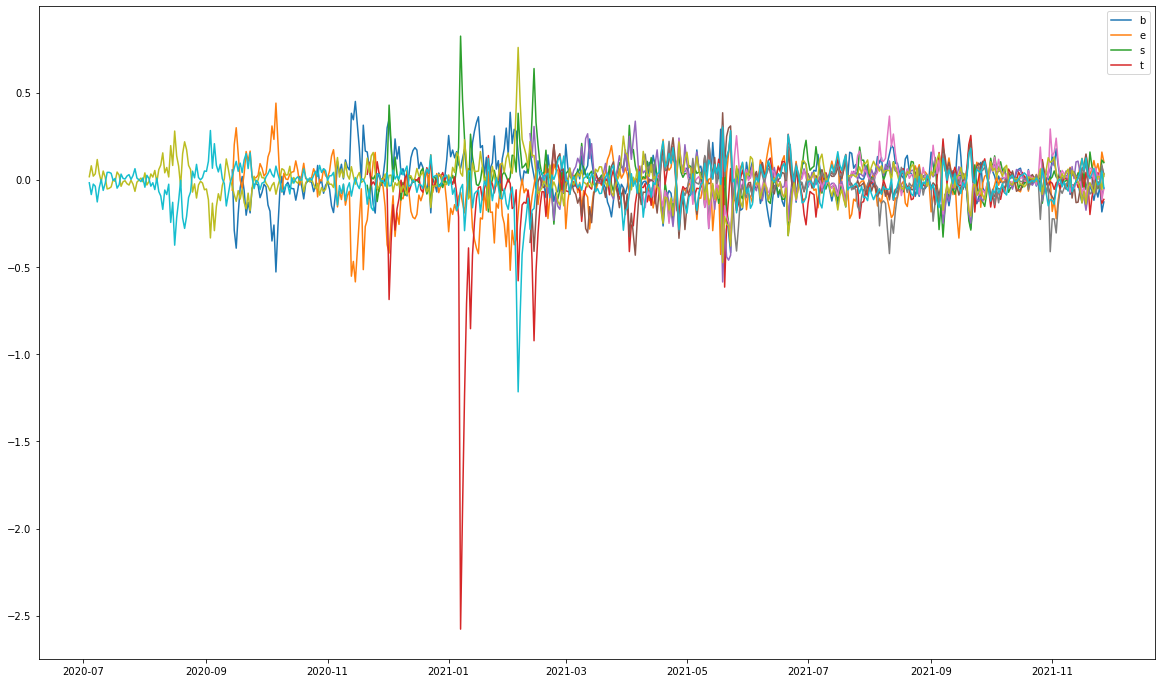

In [14]:
# make value functions
samples = dict()
for ticker in pre_samples.keys():
    sample = pre_samples[ticker].copy()
    sample['value_up'] = 0.
    sample['value_down'] = 0.
    
    for idx in sample.index:
        if idx == sample.index[0]:
            sample.loc[idx, 'value_up'] = sample.loc[idx, 'log_reward_up']
            sample.loc[idx, 'value_down'] = sample.loc[idx, 'log_reward_down']
            continue
        
        gamma = 1. - 0.5*sample.loc[idx, 'noise']
        sample.loc[idx, 'value_up'] = sample.loc[idx, 'log_reward_up'] + gamma*(sample.shift(1).loc[idx, 'value_up'])
        sample.loc[idx, 'value_down'] = sample.loc[idx, 'log_reward_down'] + gamma*(sample.shift(1).loc[idx, 'value_down'])
    samples[ticker] = sample

plt.figure(figsize=(20, 12))
for ticker in list(samples.keys())[:5]:
    plt.plot(samples[ticker].index, samples[ticker].value_up, label=f"{ticker}-up")
    plt.plot(samples[ticker].index, samples[ticker].value_down, label=f"{ticker}-down")
plt.legend('best')
plt.show()

In [15]:
book = samples['BTCUSDT'][['close']].copy()
book['number'] = book.index.map(mdates.date2num)
book['reward'] = 1.
book['value_up'] = 0.
book['value_down'] = 0.

for idx in book.index:
    if idx in [ref.index[0], ref.index[-1]]: continue
    
    # select 21 highest volume coins
    volumes = dict()
    for ticker in samples.keys():
        try:
            volumes[ticker] = samples[ticker].loc[idx, 'close']*samples[ticker].loc[idx, 'volume']
        except:
            continue
    top21v = dict(sorted(volumes.items(), key=(lambda x: x[1]), reverse=True)[:21])
    
    # select 5 up, 5 down
    values = dict()
    for ticker in samples.keys():
        try:
            values[f"{ticker}-UP"] = samples[ticker].loc[idx, 'value_up']
            values[f"{ticker}-DOWN"] = samples[ticker].loc[idx, 'value_down']
        except:
            continue
    res = dict(sorted(values.items(), key=(lambda x: x[1]), reverse=True)[:6])
    
    book.loc[idx, 'value'] = np.mean(list(res.values()))
    
    reward = 0.
    leverage = 1.
    ratio = 1/len(res)
    
    for coin in res.keys():
        if "UP" in coin:
            ticker = coin[:-3]
            if samples[ticker].loc[idx, 'momentum'] < 0.3:
                reward += ratio
            elif samples[ticker].loc[idx, 'momentum'] < 0.8:
                #reward += ratio
                reward += ratio*(1.+1.*(samples[ticker].shift(-1).loc[idx, 'reward_up']-1.002))
            else:
                if samples[ticker].loc[idx, 'close']/samples[ticker].shift(-1).loc[idx, 'low'] < 0.5:
                    reward += 0.
                else:
                    reward += ratio*(1.+2.*(samples[ticker].shift(-1).loc[idx, 'reward_up']-1.002))
        else:
            ticker = coin[:-5]
            if samples[ticker].loc[idx, 'momentum'] > -0.2:
                reward += ratio
            elif samples[ticker].loc[idx, 'momentum'] > -0.6:
                if samples[ticker].loc[idx, 'close']/samples[ticker].shift(-1).loc[idx, 'low'] < 0.5:
                    reward += 0.
                else:
                    reward += ratio*(1.+2.*(samples[ticker].shift(-1).loc[idx, 'reward_up']-1.002))
            else:
                if samples[ticker].loc[idx, 'close']/samples[ticker].shift(-1).loc[idx, 'low'] < 0.8:
                    reward += 0.
                else:
                    reward += ratio*(1.+5.*(samples[ticker].shift(-1).loc[idx, 'reward_up']-1.002))
    book.loc[idx, 'reward'] = reward
book.dropna(inplace=True)
book.tail(20)    

,close,number,reward,value_up,value_down,value
datetime,,,,,,
2021-11-07,63316.40,18938.0,1.089419,0.0,0.0,0.275730
2021-11-08,67606.96,18939.0,1.124962,0.0,0.0,0.260669
2021-11-09,67009.98,18940.0,0.988349,0.0,0.0,0.325926
2021-11-10,64920.13,18941.0,1.004889,0.0,0.0,0.258093
2021-11-11,64831.30,18942.0,1.016308,0.0,0.0,0.223347
2021-11-12,64156.08,18943.0,0.936778,0.0,0.0,0.187411
2021-11-13,64427.00,18944.0,0.989925,0.0,0.0,0.109834
2021-11-14,65568.39,18945.0,0.990518,0.0,0.0,0.137086
2021-11-15,63654.49,18946.0,0.943912,0.0,0.0,0.132331


==== value trading ====
Accumulated Returns: 119523.22 %
CAGR: 4241.23 %
MDD: -65.9 %
VOL: 210.117 %
Sharpe: 17635.44 %


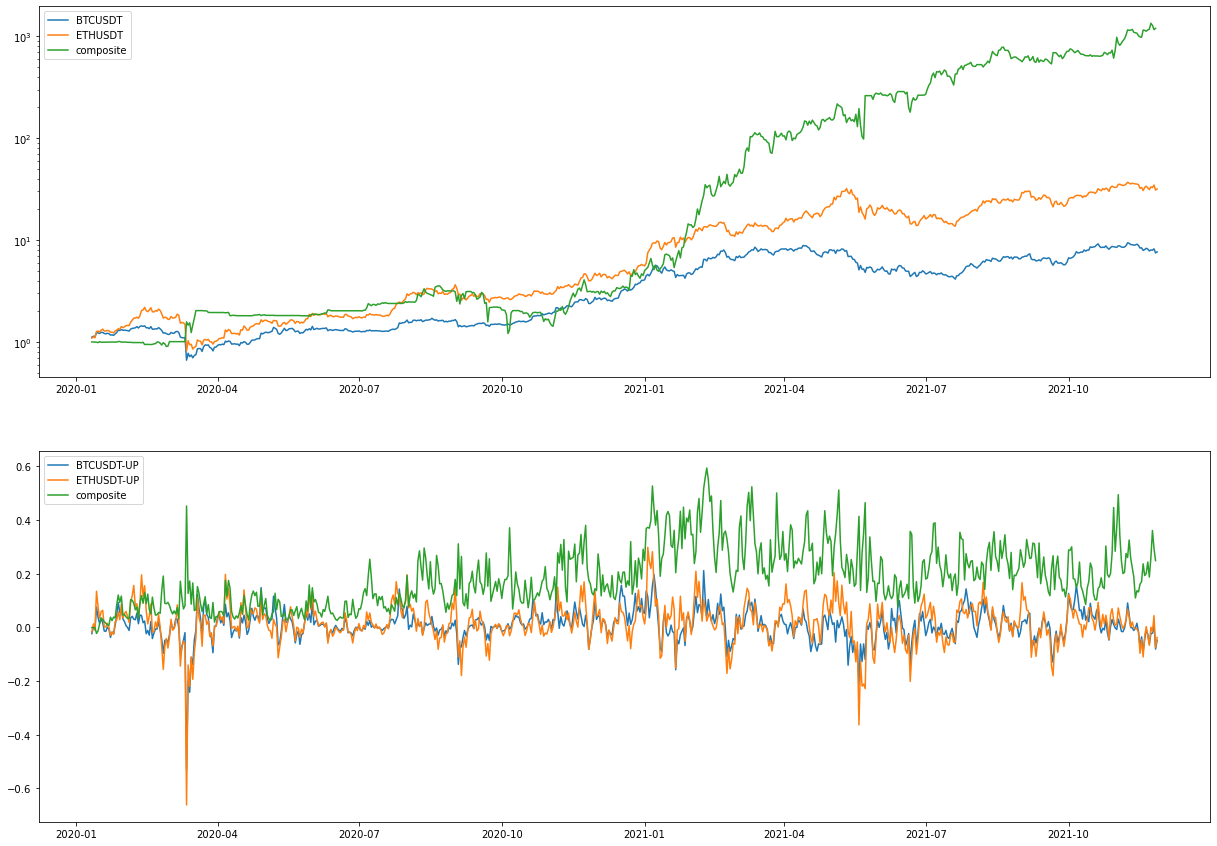

In [16]:
# evaluate
total_reward = 1.
for idx in book.index:
    total_reward *= book.loc[idx, 'reward']
    book.loc[idx, 'total_reward'] = total_reward
CAGR = book['total_reward'].iloc[-1]**(365./len(book.index)) - 1.

historical_max = book['total_reward'].cummax()
daily_drawdown = book['total_reward']/historical_max - 1.
historical_dd = daily_drawdown.cummin()
MDD = historical_dd.min()
VOL = np.std(book['reward'])*np.sqrt(365.)
Sharpe = (np.mean(book['reward'])/np.std(book['reward'])*np.sqrt(365.))

print("==== value trading ====")
print("Accumulated Returns:", round((total_reward-1.)*100, 2), "%")
print("CAGR:", round(CAGR*100, 2), "%")
print("MDD:", round(MDD*100, 2), "%")
print("VOL:", round(VOL*100, 3), "%")
print("Sharpe:", round(Sharpe*100,2), "%")

plt.figure(figsize=(21, 15))
plt.subplot(2, 1, 1)
plt.yscale('log')
plt.plot(samples['BTCUSDT'].index, samples['BTCUSDT'].total_reward, label="BTCUSDT")
plt.plot(samples['ETHUSDT'].index, samples['ETHUSDT'].total_reward, label="ETHUSDT")
plt.plot(book.index, book.total_reward, label='composite')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.plot(samples['BTCUSDT'].index, samples['BTCUSDT'].value_up, label="BTCUSDT-UP")
plt.plot(samples['ETHUSDT'].index, samples['ETHUSDT'].value_up, label="ETHUSDT-UP")
plt.plot(book.index, book.value, label="composite")
plt.legend(loc='best')

plt.show()